# Distributions - Container

Container SIDE. + comparison with native

This experiment try to stress the behavior of the sorting algorithm based on the keys distribution.\
Three types of distribution are tested:

1. uniform
2. few-unique
3. skewed

Here is reported the common configuration for all the experiments:

* **n_keys** : $10^9$
* **n_ranks** : $16$
* **n_threads** : $4$
* **merging_strategy** : binary
* **sorting_algorithm** : radix

Experiments were executed on [**Orfeo, partition GENOA**](https://orfeo-doc.areasciencepark.it/HPC/computational-resources/).

The key metrics here are **time_communication_seconds** and **total_time_seconds**.

In [23]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [24]:
native_results = pd.read_csv("../parallel/results/distributions.csv")
native_results = native_results[
    ["n_key","n_ranks", "distribution", "time_communication_seconds", "time_total_seconds"]
]
native_results["container"] = 0
native_results.head()


,n_key,n_ranks,distribution,time_communication_seconds,time_total_seconds,container
0,1000000000,16,uniform,0.369443,3.998779,0
1,1000000000,16,skewed,0.660825,4.037580,0
2,1000000000,16,few-unique,0.573044,3.247684,0
3,1000000000,16,uniform,0.455500,4.036865,0
4,1000000000,16,skewed,0.653498,4.018667,0


In [ ]:
container_results = pd.read_csv("../parallel/results/container_distributions.csv")
container_results = container_results[
    ["n_key", "n_ranks", "distribution", "time_communication_seconds", "time_total_seconds"]
]
container_results["version"] = "container"
container_results.head()

,n_key,n_ranks,distribution,time_communication_seconds,time_total_seconds,container
0,1000000000,16,uniform,2.422269,6.013626,1
1,1000000000,16,skewed,1.628468,4.561577,1
2,1000000000,16,few-unique,1.585891,4.416353,1
3,1000000000,16,uniform,2.554295,6.134030,1
4,1000000000,16,skewed,1.586280,4.569964,1


In [26]:
results = pd.merge(native_results, container_results, "outer")
results.head(30)

,n_key,n_ranks,distribution,time_communication_seconds,time_total_seconds,container
0,1000000000,16,few-unique,0.573044,3.247684,0
1,1000000000,16,few-unique,0.648081,3.356501,0
2,1000000000,16,few-unique,0.654203,3.397909,0
3,1000000000,16,few-unique,0.666963,3.422759,0
4,1000000000,16,few-unique,1.525968,4.370866,1
5,1000000000,16,few-unique,1.570374,4.380848,1
6,1000000000,16,few-unique,1.585891,4.416353,1
7,1000000000,16,few-unique,1.637623,4.448612,1
8,1000000000,16,skewed,0.442317,4.058889,0
9,1000000000,16,skewed,0.630547,4.080577,0


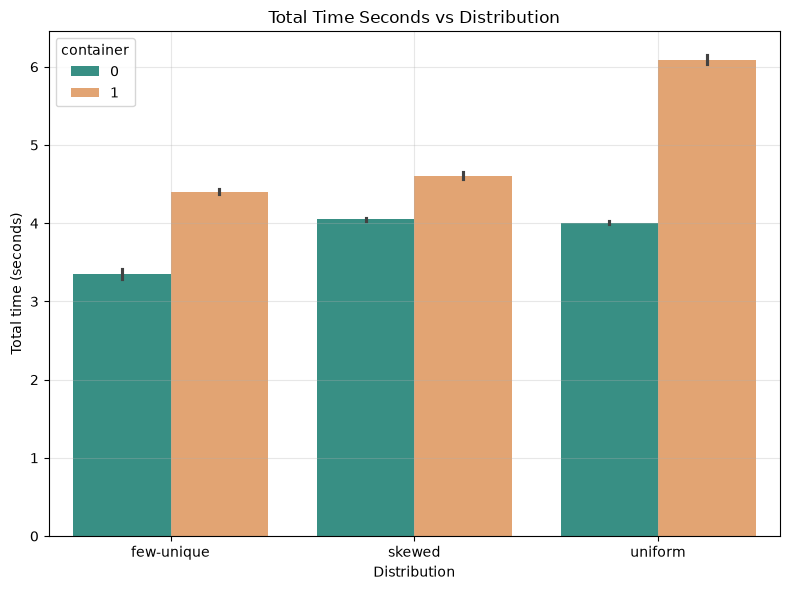

In [ ]:
custom_palette = {
    "container": "#2a9d8f",
    "native": "#f4a261"
}

plt.figure(figsize=(8, 6))

sns.barplot(
    data=results,
    x="distribution",
    y="time_total_seconds",
    hue="container",
    palette=custom_palette,
    legend=True
)

plt.xlabel("Distribution")
plt.ylabel("Total time (seconds)")
plt.title(f"Total Time Seconds vs Distribution")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

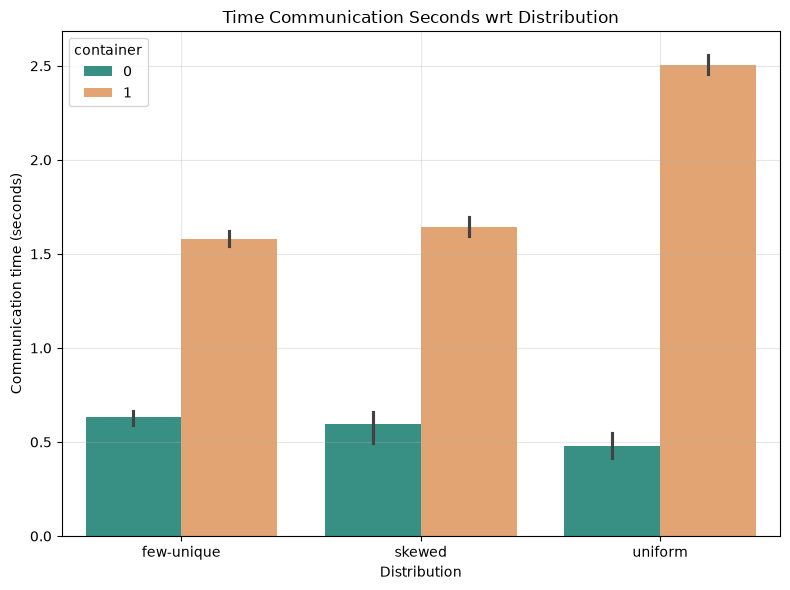

In [28]:

plt.figure(figsize=(8, 6))

sns.barplot(
    data=results,
    x="distribution",
    y="time_communication_seconds",
    hue="container",
    palette=custom_palette,
    legend=True
)

plt.xlabel("Distribution")
plt.ylabel("Communication time (seconds)")
plt.title(f"Time Communication Seconds wrt Distribution")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()